In [90]:
# imports
!pip install split-folders
import torch
from torch import nn
import kagglehub
import os
import shutil
import splitfolders
import random
from PIL import Image
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from typing import List
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from google.colab import files

In [63]:
print(f"Torch Version: {torch.__version__}")
print(f"Kagglehub Version: {kagglehub.__version__}")

Torch Version: 2.10.0+cu128
Kagglehub Version: 1.0.0


In [64]:
# set up device-agnostic code
device = "cuda" if torch.cuda.is_available() else 'cpu'

In [65]:
# Download latest version
path = kagglehub.dataset_download("hasyimabdillah/workoutexercises-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'workoutexercises-images' dataset.
Path to dataset files: /kaggle/input/workoutexercises-images


In [66]:
! pip install split-folders

# 1. Define the source path where kagglehub downloaded your dataset
kaggle_dataset_path = "/root/.cache/kagglehub/datasets/hasyimabdillah/workoutexercises-images/versions/15"

# 2. Define a temporary directory to hold ONLY your 5 chosen exercises
temp_subset_dir = "./workout_subset"
os.makedirs(temp_subset_dir, exist_ok=True)

# 3. Select your 5 core exercises (matching the folder names in the dataset)
chosen_exercises = ["squat", "push up", "plank", "pull up", "deadlift"]

# 4. Copy only the selected folders to our temporary directory
print("Filtering dataset for selected exercises...")
for exercise in chosen_exercises:
    source_folder = os.path.join(kaggle_dataset_path, exercise)
    destination_folder = os.path.join(temp_subset_dir, exercise)

    if os.path.exists(source_folder):
        # copy the entire folder contents from source --> destination
        shutil.copytree(source_folder, destination_folder)
        print(f"✅ Copied: {exercise}")
    else:
        print(f"❌ Error: Folder '{exercise}' not found in source path. Check spelling!")

# 5. Define where your final split data should go
final_output_dir = "./workout_split_data"

# 6. Apply the 80/20 train/validation split
print("\nSplitting into Train and Validation sets...")

splitfolders.ratio(
    temp_subset_dir,
    output=final_output_dir,
    # random seed for the shuffle
    seed=1337,
    ratio=(.7, .2, 0.1), # 80% Train, 20% Val
    group_prefix=None,
    move=False
)

# 7. Clean up the temporary folder to save disk space
# delete the temp directory
shutil.rmtree(temp_subset_dir)

print("\n🎉 Done! Your data is ready.")
print(f"Check the folder: '{final_output_dir}' to see your 'train' and 'val' splits.")

Filtering dataset for selected exercises...
✅ Copied: squat
✅ Copied: push up
✅ Copied: plank
✅ Copied: pull up
✅ Copied: deadlift

Splitting into Train and Validation sets...


Copying files: 3481 files [00:07, 490.97 files/s] 



🎉 Done! Your data is ready.
Check the folder: './workout_split_data' to see your 'train' and 'val' splits.


In [67]:
# inspect what is in our data directory
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [68]:
walk_through_dir(final_output_dir)

There are 3 directories and 0 images in './workout_split_data'.
There are 5 directories and 0 images in './workout_split_data/train'.
There are 0 directories and 420 images in './workout_split_data/train/push up'.
There are 0 directories and 519 images in './workout_split_data/train/squat'.
There are 0 directories and 371 images in './workout_split_data/train/deadlift'.
There are 0 directories and 695 images in './workout_split_data/train/plank'.
There are 0 directories and 430 images in './workout_split_data/train/pull up'.
There are 5 directories and 0 images in './workout_split_data/val'.
There are 0 directories and 120 images in './workout_split_data/val/push up'.
There are 0 directories and 148 images in './workout_split_data/val/squat'.
There are 0 directories and 106 images in './workout_split_data/val/deadlift'.
There are 0 directories and 198 images in './workout_split_data/val/plank'.
There are 0 directories and 123 images in './workout_split_data/val/pull up'.
There are 5 di

In [69]:
train_dir = os.path.join(final_output_dir, "train")
val_dir = os.path.join(final_output_dir, "val")
test_dir = os.path.join(final_output_dir, "test")

# **Visualize The Data**

(480, 360)


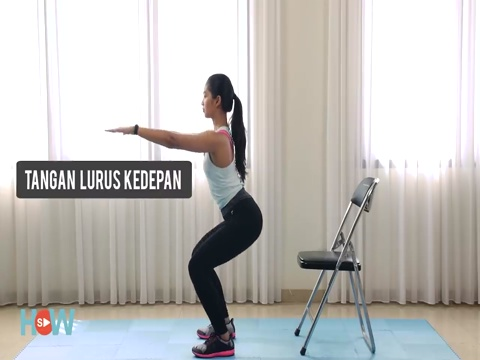

In [70]:
random.seed(1)

final_output_dir = Path(final_output_dir)

image_path_list = list(final_output_dir.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)
print(img.size)
img

In [71]:
# data augmentation
train_transform = transforms.Compose([
    transforms.Resize(232),
    # take a random 224 x 224 crop out of the input image
    transforms.RandomCrop(224),
    # 50% chance the image is flipped, 50% chance the image passes through unchanged
    transforms.RandomHorizontalFlip(p=0.5),
    # randomly perturbs the color properties of the image
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # converts image to a pytorch tensor, then rearanges dimension [HWC] --> [CHW]
    transforms.ToTensor(),
    # Look into ImageNet if interested on normalization (input - mean) / std
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
# ImageFolder assumes specific structure
# Each subfolder name becomes a class
"""
  1. Scans directory
  2. Sorts class names alphebetically
  3. Walks each subfolder and collects every image file inside it
     pairing it with its classes integer label (image_path, label)
  4. Stores the transform so it can be applied later, lazely
"""
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=eval_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=eval_transform)

print(f"train_data\n{train_dataset}\n\nval_data\n{val_dataset}\n\ntest_data\n\n{test_dataset}")

train_data
Dataset ImageFolder
    Number of datapoints: 2435
    Root location: ./workout_split_data/train
    StandardTransform
Transform: Compose(
               Resize(size=232, interpolation=bilinear, max_size=None, antialias=True)
               RandomCrop(size=(224, 224), padding=None)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

val_data
Dataset ImageFolder
    Number of datapoints: 695
    Root location: ./workout_split_data/val
    StandardTransform
Transform: Compose(
               Resize(size=232, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

test_data

Dataset ImageFolder
    Number of

In [72]:
# get class names and the class dict
class_names, class_dict = train_dataset.classes, train_dataset.class_to_idx

print(class_names)
print(class_dict)

['deadlift', 'plank', 'pull up', 'push up', 'squat']
{'deadlift': 0, 'plank': 1, 'pull up': 2, 'push up': 3, 'squat': 4}


In [73]:
len(train_dataset), len(val_dataset), len(test_dataset)

(2435, 695, 351)

In [74]:
img, label = train_dataset[0][0], train_dataset[0][1]
img.shape, label

(torch.Size([3, 224, 224]), 0)

In [75]:
# Turn Train, Val, and Test sets into DataLoaders

train_dataloader = DataLoader(
    dataset = train_dataset,
    batch_size = 32,
    num_workers = 4,
    shuffle = True,
    pin_memory = True,
    drop_last = True
)

val_dataloader = DataLoader(
    dataset = val_dataset,
    batch_size = 32,
    num_workers = 4,
    pin_memory = True
)

test_dataloader = DataLoader(
    dataset = test_dataset,
    batch_size = 32,
    num_workers = 4,
    pin_memory = True
)

In [76]:
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

  if seed:
    random.seed(seed)

  random_samples_idx = random.sample(range(len(dataset)), k = n)

  plt.figure(figsize=(16, 8))

  for i, targ_sample in enumerate(random_samples_idx):
    image, label = dataset[targ_sample][0], dataset[targ_sample][1]
    image_adjust = image.permute(1, 2, 0)
    plt.subplot(1, n, i+1)
    plt.imshow(image_adjust)
    plt.axis(False)

    if classes:
      title = f"class: {classes[label]}"
      if display_shape:
        title = title + f"\nshape: {image_adjust.shape}"
      plt.title(title)


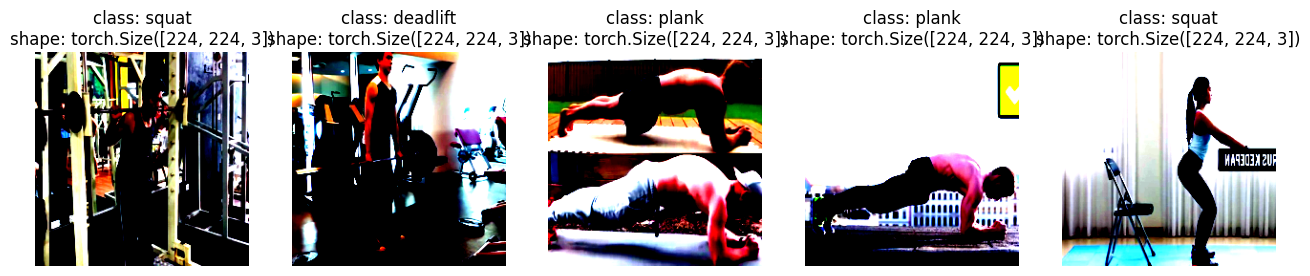

In [77]:
display_random_images(train_dataset,
                      n=5,
                      classes=class_names,
                      seed=None)

In [78]:
"""
Note, plt.imshow wont display the tensors
correctly, after normalizing the values are between [-2, 2],
not [0, 1]. matplotlib will clip them and the images will look weird
"""

'\nNote, plt.imshow wont display the tensors \ncorrectly, after normalizing the values are between [-2, 2],\nnot [0, 1]. matplotlib will clip them and the images will look weird\n'

In [79]:
# FIX

def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    if seed:
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)), k=n)

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    plt.figure(figsize=(16, 8))

    for i, targ_sample in enumerate(random_samples_idx):
        image, label = dataset[targ_sample]
        image_adjust = image.permute(1, 2, 0) * std + mean
        image_adjust = image_adjust.clamp(0, 1)

        plt.subplot(1, n, i + 1)
        plt.imshow(image_adjust)
        plt.axis(False)

        if classes:
            title = f"class: {classes[label]}"
            if display_shape:
                title += f"\nshape: {image_adjust.shape}"
            plt.title(title)

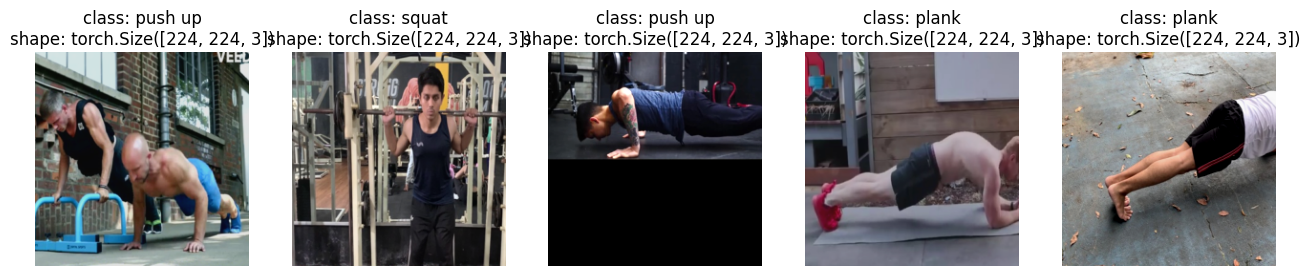

In [80]:
display_random_images(train_dataset,
                      n=5,
                      classes=class_names,
                      seed=None)

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


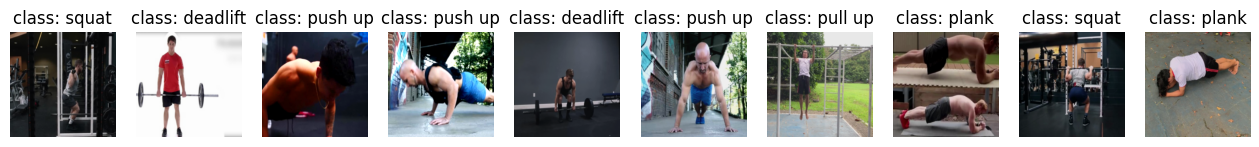

In [81]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_dataset,
                      n=12,
                      classes=class_names,
                      seed=None) # Try setting the seed for reproducible images

In [82]:
"""
  download and load pretrained weights into the architecture
"""
model_0 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# get the number of classes
num_classes = len(class_names)

"""
  Replace the final layer:
    - ResNet50's last layer is a fully-connected layer (fc)
    - Generally, it's shape is (in_features=2048, out_features=1000)
    - Instead of 1000, we want the out_features to be len(num_classes)
    - Overwrite the fc layer
"""
model_0.fc = nn.Linear(model_0.fc.in_features, num_classes)
model_0 = model_0.to(device)

In [83]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

In [84]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):

    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [85]:
def eval_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):

    model.eval()
    eval_loss, eval_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            eval_loss += loss.item()

            y_pred_class = torch.argmax(y_pred, dim=1)
            eval_acc += (y_pred_class == y).sum().item() / len(y_pred)

    eval_loss = eval_loss / len(dataloader)
    eval_acc = eval_acc / len(dataloader)
    return eval_loss, eval_acc

In [86]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        val_loss, val_acc = eval_step(model=model,
                                      dataloader=val_dataloader,
                                      loss_fn=loss_fn,
                                      device=device)

        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    return results

In [87]:
results = train(
    model=model_0,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    device=device,
    epochs=5,
)

# Final test eval — only after all training and tuning decisions are made
test_loss, test_acc = eval_step(model=model_0,
                                dataloader=test_dataloader,
                                loss_fn=loss_fn,
                                device=device)
print(f"Test | loss: {test_loss:.4f} | acc: {test_acc:.4f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.2068 | train_acc: 0.9428 | val_loss: 0.3723 | val_acc: 0.8878
Epoch: 2 | train_loss: 0.0887 | train_acc: 0.9696 | val_loss: 0.3952 | val_acc: 0.8533
Epoch: 3 | train_loss: 0.0882 | train_acc: 0.9745 | val_loss: 0.3813 | val_acc: 0.9460
Epoch: 4 | train_loss: 0.0689 | train_acc: 0.9770 | val_loss: 0.0596 | val_acc: 0.9858
Epoch: 5 | train_loss: 0.0351 | train_acc: 0.9885 | val_loss: 0.0163 | val_acc: 0.9915
Test | loss: 0.0202 | acc: 0.9915


In [89]:
!pip install gradio

import gradio as gr
from PIL import Image
import torch

def predict(image):
    # image is a PIL Image passed in by Gradio
    image = image.convert("RGB")
    image_tensor = eval_transform(image).unsqueeze(0).to(device)

    model_0.eval()
    with torch.inference_mode():
        logits = model_0(image_tensor)
        probs = torch.softmax(logits, dim=1)[0]

    # Return dict of {class_name: probability} — Gradio renders this as a bar chart
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Exercise Classifier",
    description="Upload an image of an exercise to classify it.",
)

demo.launch(share=True)   # share=True gives you a public URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3dcd6ade743075c694.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [91]:
torch.save(model_0.state_dict(), "model.pth")

files.download("model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>